Précision sur données originales : 0.488
Précision sur projection Kernel PCA : 0.988


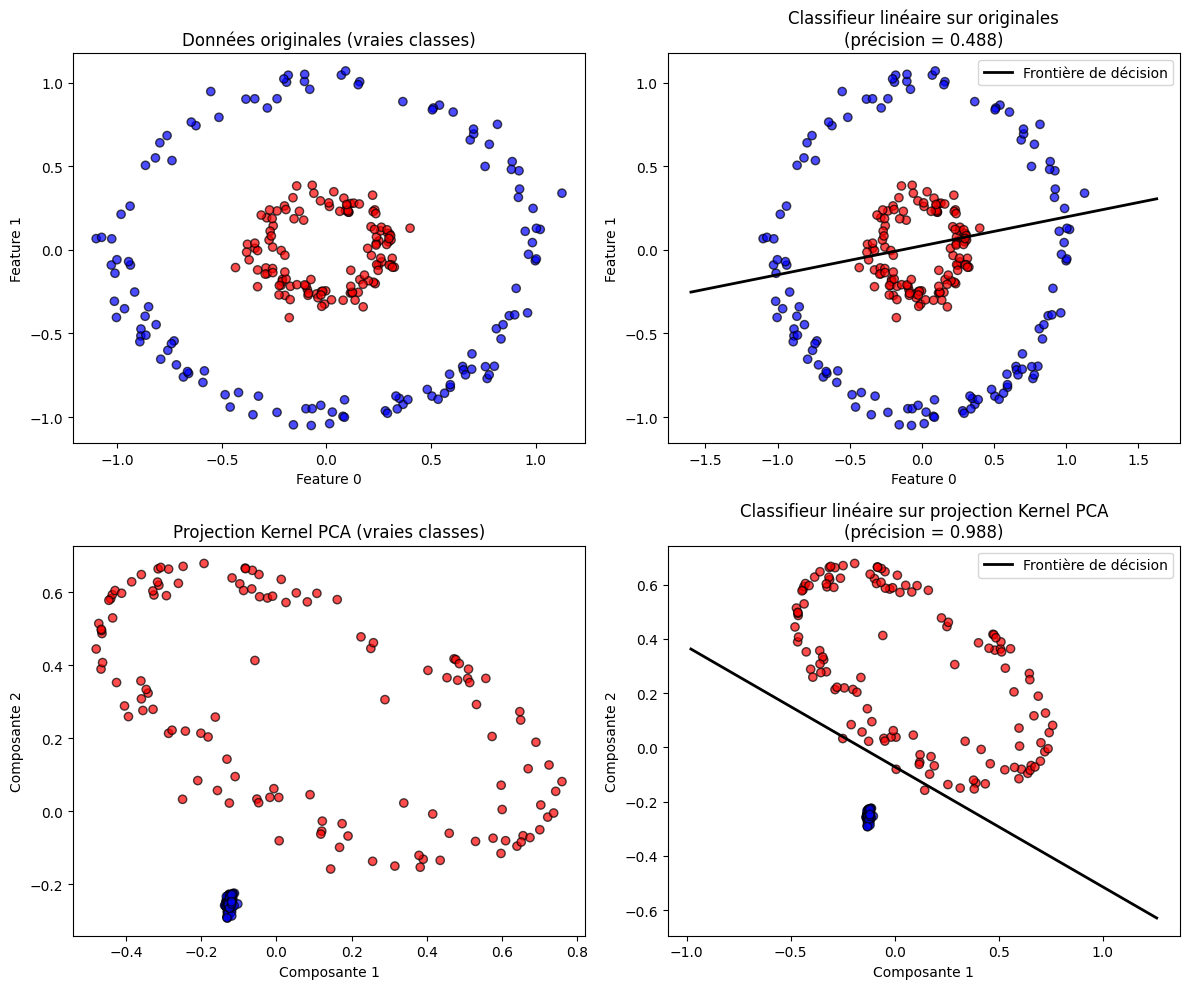

In [14]:
# ========================================================
# Kernel PCA + classification linéaire (régression logistique)
# Visualisation avec la frontière de décision
# ========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Données (identique à l'exemple scikit‑learn)
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

# 2. Kernel PCA (RBF) sur les données d'entraînement
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)

# 3. Classifieurs linéaires
clf_orig = LogisticRegression()
clf_orig.fit(X_train, y_train)
y_pred_orig = clf_orig.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred_orig)

clf_proj = LogisticRegression()
clf_proj.fit(X_train_kpca, y_train)
y_pred_proj = clf_proj.predict(X_test_kpca)
acc_proj = accuracy_score(y_test, y_pred_proj)

print(f"Précision sur données originales : {acc_orig:.3f}")
print(f"Précision sur projection Kernel PCA : {acc_proj:.3f}")

# 4. Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Données originales – vraies classes
axes[0,0].scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr', edgecolors='k', alpha=0.7)
axes[0,0].set_title("Données originales (vraies classes)")
axes[0,0].set_xlabel("Feature 0")
axes[0,0].set_ylabel("Feature 1")

# (b) Données originales – frontière de décision linéaire
# Tracer la droite de décision : w0*x0 + w1*x1 + b = 0
xx = np.linspace(X_test[:,0].min()-0.5, X_test[:,0].max()+0.5, 100)
coef = clf_orig.coef_[0]
intercept = clf_orig.intercept_[0]
yy = -(coef[0]*xx + intercept) / coef[1]
axes[0,1].scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr', edgecolors='k', alpha=0.7)
axes[0,1].plot(xx, yy, 'k-', linewidth=2, label='Frontière de décision')
axes[0,1].set_title(f"Classifieur linéaire sur originales\n(précision = {acc_orig:.3f})")
axes[0,1].set_xlabel("Feature 0")
axes[0,1].set_ylabel("Feature 1")
axes[0,1].legend()

# (c) Projection Kernel PCA – vraies classes
axes[1,0].scatter(X_test_kpca[:,0], X_test_kpca[:,1], c=y_test, cmap='bwr', edgecolors='k', alpha=0.7)
axes[1,0].set_title("Projection Kernel PCA (vraies classes)")
axes[1,0].set_xlabel("Composante 1")
axes[1,0].set_ylabel("Composante 2")

# (d) Projection Kernel PCA – frontière de décision linéaire
xx2 = np.linspace(X_test_kpca[:,0].min()-0.5, X_test_kpca[:,0].max()+0.5, 100)
coef2 = clf_proj.coef_[0]
intercept2 = clf_proj.intercept_[0]
yy2 = -(coef2[0]*xx2 + intercept2) / coef2[1]
axes[1,1].scatter(X_test_kpca[:,0], X_test_kpca[:,1], c=y_test, cmap='bwr', edgecolors='k', alpha=0.7)
axes[1,1].plot(xx2, yy2, 'k-', linewidth=2, label='Frontière de décision')
axes[1,1].set_title(f"Classifieur linéaire sur projection Kernel PCA\n(précision = {acc_proj:.3f})")
axes[1,1].set_xlabel("Composante 1")
axes[1,1].set_ylabel("Composante 2")
axes[1,1].legend()

plt.tight_layout()
plt.show()

Précision classifieur linéaire (original) : 0.488
Précision SVM RBF (original)             : 1.000
Précision linéaire après Kernel PCA      : 0.988


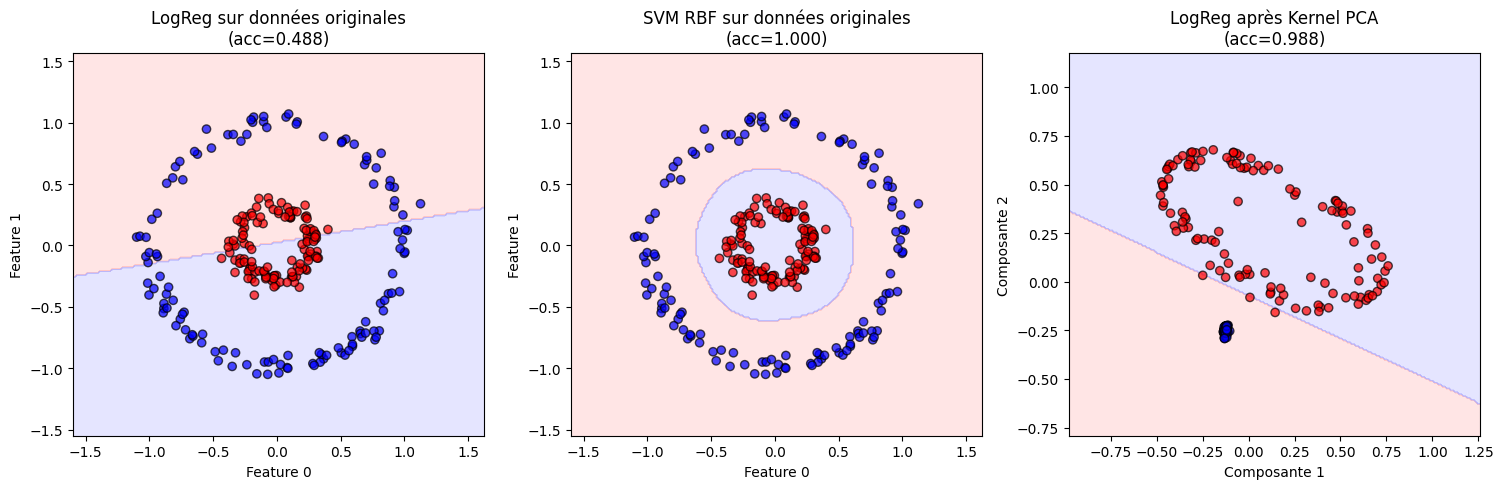

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# 1. Données
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

# 2. Classifieur linéaire sur données originales
clf_linear = LogisticRegression()
clf_linear.fit(X_train, y_train)
acc_linear = accuracy_score(y_test, clf_linear.predict(X_test))

# 3. SVM avec noyau RBF sur données originales
svm_rbf = SVC(kernel='rbf', gamma=10, C=1)
svm_rbf.fit(X_train, y_train)
acc_svm = accuracy_score(y_test, svm_rbf.predict(X_test))

# 4. Kernel PCA + classifieur linéaire
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)
clf_kpca_linear = LogisticRegression()
clf_kpca_linear.fit(X_train_kpca, y_train)
acc_kpca = accuracy_score(y_test, clf_kpca_linear.predict(X_test_kpca))

print(f"Précision classifieur linéaire (original) : {acc_linear:.3f}")
print(f"Précision SVM RBF (original)             : {acc_svm:.3f}")
print(f"Précision linéaire après Kernel PCA      : {acc_kpca:.3f}")

# 5. Visualisation des frontières de décision
def plot_decision_boundary(ax, model, X, y, title, is_kpca=False):
    # Créer une grille
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Feature 0" if not is_kpca else "Composante 1")
    ax.set_ylabel("Feature 1" if not is_kpca else "Composante 2")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original – classifieur linéaire
plot_decision_boundary(axes[0], clf_linear, X_test, y_test,
                       f"LogReg sur données originales\n(acc={acc_linear:.3f})")

# Original – SVM RBF
plot_decision_boundary(axes[1], svm_rbf, X_test, y_test,
                       f"SVM RBF sur données originales\n(acc={acc_svm:.3f})")

# Kernel PCA + classifieur linéaire
plot_decision_boundary(axes[2], clf_kpca_linear, X_test_kpca, y_test,
                       f"LogReg après Kernel PCA\n(acc={acc_kpca:.3f})", is_kpca=True)

plt.tight_layout()
plt.show()

Précisions sur données de test :
Régression logistique        : 0.488
SVM linéaire                 : 0.636
SVM RBF                      : 1.000
Kernel PCA + LogReg          : 0.988


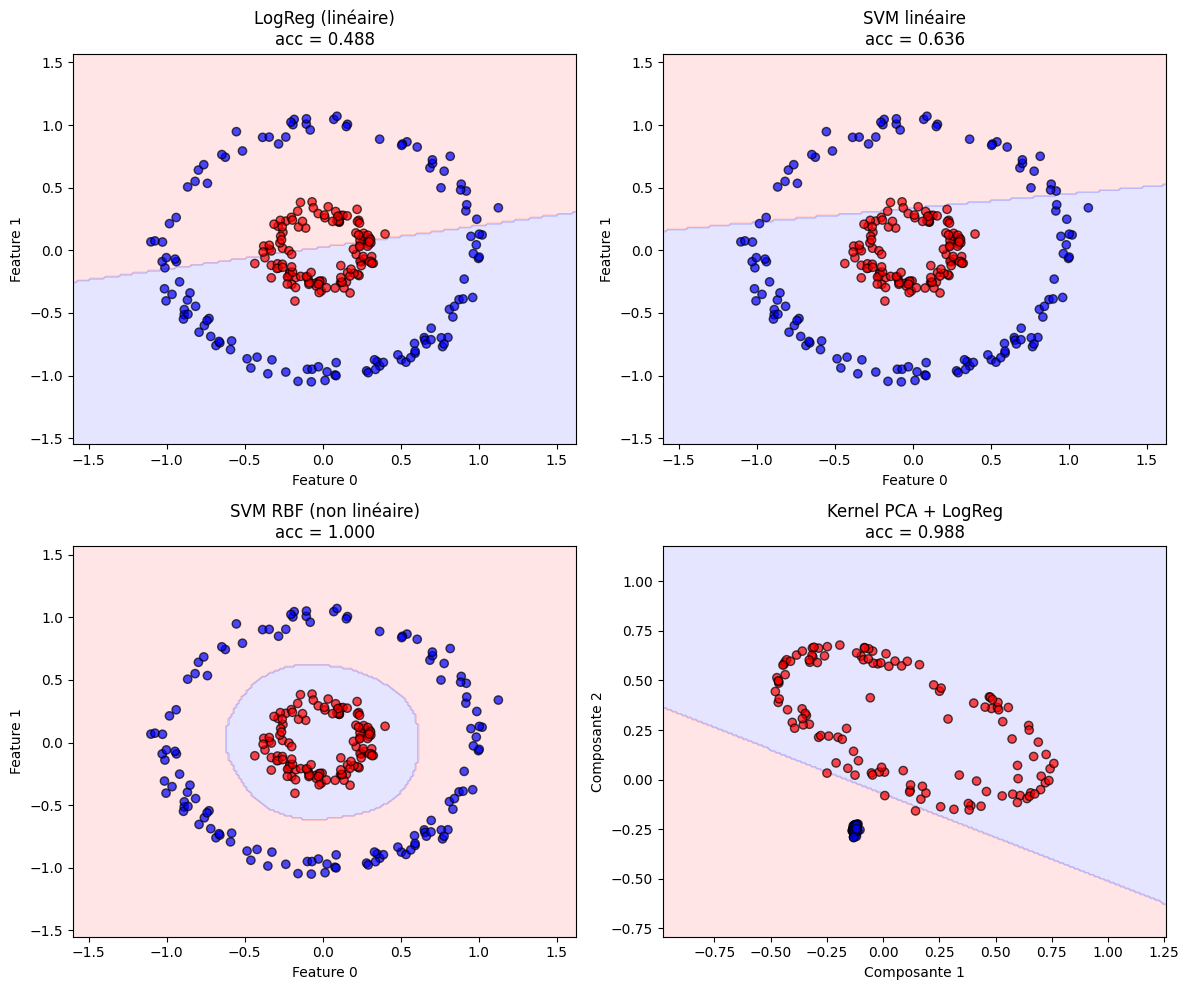

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# 1. Données
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

# 2. Classifieurs
# (a) Régression logistique (linéaire)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

# (b) SVM linéaire
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
acc_svm_linear = accuracy_score(y_test, svm_linear.predict(X_test))

# (c) SVM RBF (non linéaire)
svm_rbf = SVC(kernel='rbf', gamma=10, C=1)
svm_rbf.fit(X_train, y_train)
acc_svm_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))

# (d) Kernel PCA + classifieur linéaire (LogReg)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)
logreg_kpca = LogisticRegression()
logreg_kpca.fit(X_train_kpca, y_train)
acc_kpca = accuracy_score(y_test, logreg_kpca.predict(X_test_kpca))

print("Précisions sur données de test :")
print(f"Régression logistique        : {acc_logreg:.3f}")
print(f"SVM linéaire                 : {acc_svm_linear:.3f}")
print(f"SVM RBF                      : {acc_svm_rbf:.3f}")
print(f"Kernel PCA + LogReg          : {acc_kpca:.3f}")

# 3. Visualisation des frontières de décision
def plot_decision_boundary(ax, model, X, y, title, is_kpca=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Feature 0" if not is_kpca else "Composante 1")
    ax.set_ylabel("Feature 1" if not is_kpca else "Composante 2")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (1) Régression logistique
plot_decision_boundary(axes[0,0], logreg, X_test, y_test,
                       f"LogReg (linéaire)\nacc = {acc_logreg:.3f}")

# (2) SVM linéaire
plot_decision_boundary(axes[0,1], svm_linear, X_test, y_test,
                       f"SVM linéaire\nacc = {acc_svm_linear:.3f}")

# (3) SVM RBF
plot_decision_boundary(axes[1,0], svm_rbf, X_test, y_test,
                       f"SVM RBF (non linéaire)\nacc = {acc_svm_rbf:.3f}")

# (4) Kernel PCA + LogReg
plot_decision_boundary(axes[1,1], logreg_kpca, X_test_kpca, y_test,
                       f"Kernel PCA + LogReg\nacc = {acc_kpca:.3f}", is_kpca=True)

plt.tight_layout()
plt.show()